<a href="https://colab.research.google.com/github/springboardmentor112r-Agri/Oil_Spill_Detection-/blob/AI_OSD-LeishaJain/OilSpillDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
image_dir = "/content/drive/MyDrive/sos-dataset/dataset/train/sentinel/image/"
label_dir="/content/drive/MyDrive/sos-dataset/dataset/train/sentinel/label/"

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
import cv2


In [5]:
image_files=sorted(os.listdir(image_dir))
label_files=sorted(os.listdir(label_dir))
print("Total Images: ",len(image_files))
print("Total Labels: ",len(label_files))

Total Images:  3354
Total Labels:  3354


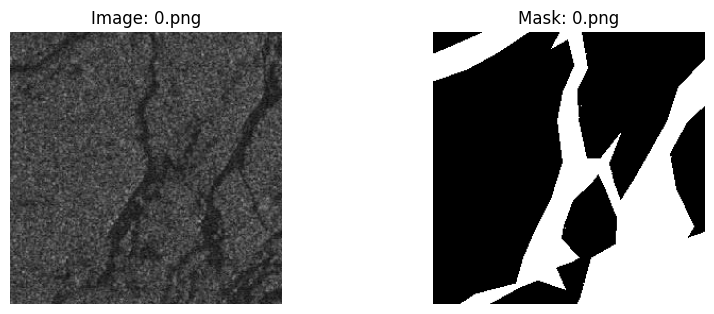

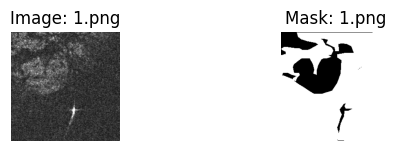

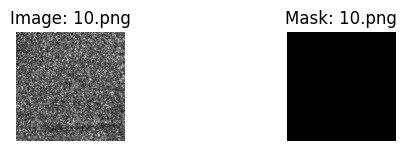

In [6]:
def show_samples(num=3):
  plt.figure(figsize=(10, 4*num))

  for i in range (num):
    img_path=os.path.join(image_dir,image_files[i])
    label_path=os.path.join(label_dir,label_files[i])

    img=np.array(Image.open(img_path))
    label=np.array(Image.open(label_path))

    plt.subplot(num,2,2*i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Image: {image_files[i]}")
    plt.axis('off')



        # show mask
    plt.subplot(num, 2, 2*i+2)
    plt.imshow(label, cmap='gray')
    plt.title(f"Mask: {label_files[i]}")
    plt.axis('off')

    plt.show()

show_samples(3)


In [7]:
#check image and label dimensions
sample_img=np.array(Image.open(os.path.join(image_dir,image_files[0])))
sample_label=np.array(Image.open(os.path.join(label_dir,label_files[0])))
print("Image Shape: ",sample_img.shape)
print("Label Shape: ",sample_label.shape)

Image Shape:  (256, 256, 3)
Label Shape:  (256, 256, 3)


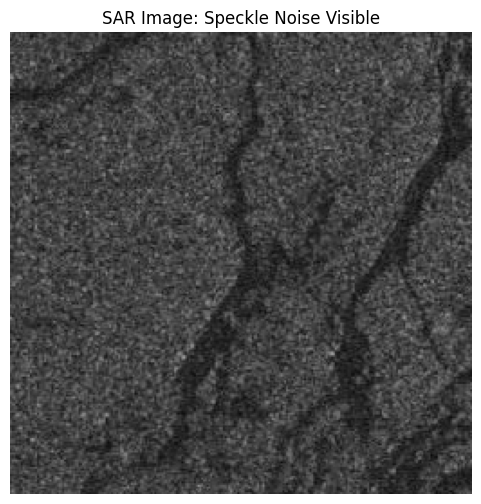

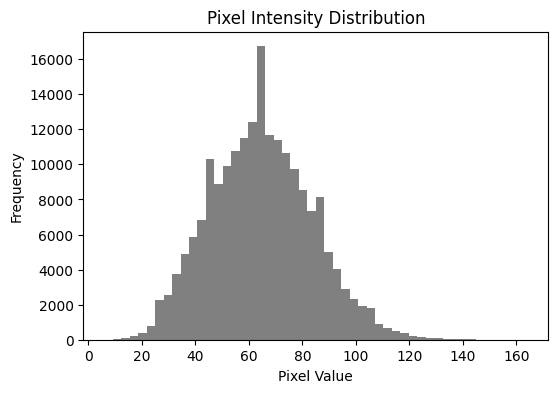

In [8]:
#observe SAR noise and pixel intensity
plt.figure(figsize=(6,6))
plt.imshow(sample_img,cmap='gray')
plt.title("SAR Image: Speckle Noise Visible")
plt.axis('off')
plt.show()

plt.figure(figsize=(6,4))
plt.hist(sample_img.flatten(), bins=50, color="gray")
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()



In [10]:
#Preprocessing

In [9]:
IMG_SIZE=(256,256)

def preprocess_img(img):
    if isinstance(img, np.ndarray):
        img = Image.fromarray(img)
    img=img.resize(IMG_SIZE)
    img_np=np.array(img)
    img_np=img_np/255.0
    img_np=cv2.medianBlur((img_np*255).astype(np.uint8),3)/255.0
    return img_np


def preprocess_label(label):
  if isinstance(label, np.ndarray):
      label = Image.fromarray(label)
  label=label.resize(IMG_SIZE)
  label_np=np.array(label)
  label_np = (label_np > 0).astype(np.uint8)
  return label_np

def augment_img(img):
  return np.fliplr(img)

def augment_label(label):
  return np.fliplr(label)

preprocessed_img=preprocess_img(sample_img)
preprocessed_label=preprocess_label(sample_label)

aug_img=augment_img(preprocessed_img)
aug_label=augment_label(preprocessed_label)

In [11]:
#module 3: model development

In [12]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
  def __init__(self,in_channels,out_channels):
    super(DoubleConv,self).__init__()
    self.net=nn.Sequential(
        nn.Conv2d(in_channels,out_channels,kernel_size=3,padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(inplace=True)
    )
  def forward(self,x):
    return self.net(x)


class UNet(nn.Module):
  def __init__(self,in_channels=3,out_channels=1):
    super(UNet,self).__init__()

    self.enc1=DoubleConv(in_channels,64)
    self.enc2=DoubleConv(64,128)
    self.enc3=DoubleConv(128,256)
    self.enc4=DoubleConv(256,512)

    self.pool=nn.MaxPool2d(2)

    self.bottleneck=DoubleConv(512,1024)

    self.up4=nn.ConvTranspose2d(1024,512,kernel_size=2,stride=2)
    self.dec4=DoubleConv(1024,512)

    self.up3=nn.ConvTranspose2d(512,256,kernel_size=2,stride=2)
    self.dec3=DoubleConv(512,256)

    self.up2=nn.ConvTranspose2d(256,128,kernel_size=2,stride=2)
    self.dec2=DoubleConv(256,128)

    self.up1=nn.ConvTranspose2d(128,64,kernel_size=2,stride=2)
    self.dec1=DoubleConv(128,64)

    self.final_cov=nn.Conv2d(64,out_channels,kernel_size=1)

  def forward(self,x):
    e1=self.enc1(x)
    p1=self.pool(e1)

    e2=self.enc2(p1)
    p2=self.pool(e2)

    e3=self.enc3(p2)
    p3=self.pool(e3)

    e4=self.enc4(p3)
    p4=self.pool(e4)

    b=self.bottleneck(p4)

    u4=self.up4(b)
    u4=torch.cat((u4,e4),dim=1)
    d4=self.dec4(u4)

    u3=self.up3(d4)
    u3=torch.cat((u3,e3),dim=1)
    d3=self.dec3(u3)

    u2=self.up2(d3)
    u2=torch.cat((u2,e2),dim=1)
    d2=self.dec2(u2)

    u1=self.up1(d2)
    u1=torch.cat((u1,e1),dim=1)
    d1=self.dec1(u1)

    output=self.final_cov(d1)
    return output


#automatically detect number of input channels

if len(sample_img.shape)==2:
  in_channels=1
else:
  in_channels=sample_img.shape[2]

print("Detected input channels:", in_channels)
model = UNet(in_channels=in_channels, out_channels=1)



Detected input channels: 3


In [13]:
#creating dataset class
from torch.utils.data import Dataset

class OilSpillDataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.image_dir, self.images[idx])).convert("L")
        mask = Image.open(os.path.join(self.mask_dir, self.masks[idx])).convert("L")

        img = preprocess_img(np.array(img))
        mask = preprocess_label(np.array(mask))

        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return img, mask


In [23]:
from torch.utils.data import DataLoader

train_dataset = OilSpillDataset(
    "/content/drive/MyDrive/sos-dataset/dataset/test/sentinel/image/",
    "/content/drive/MyDrive/sos-dataset/dataset/test/sentinel/label/"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)



In [24]:
#loss functions
def dice_loss(pred, target, smooth=1.):
    pred = torch.sigmoid(pred)
    intersection = (pred * target).sum()
    return 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
bce = nn.BCEWithLogitsLoss()

def combined_loss(pred, target):
    return bce(pred, target) + dice_loss(pred, target)


In [25]:
#optimizer
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet(in_channels=1, out_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [26]:
#training loop
epochs = 1

for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    for imgs, masks in train_loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = combined_loss(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.4f}")


KeyboardInterrupt: 

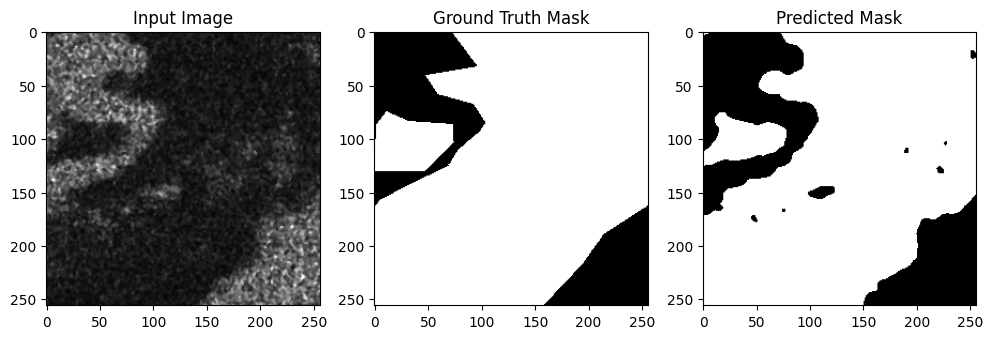

In [27]:
#visualizing one prediction
model.eval()
img, mask = train_dataset[0]

with torch.no_grad():
    pred = torch.sigmoid(model(img.unsqueeze(0).to(device)))[0][0].cpu().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img[0], cmap='gray')
plt.title("Input Image")

plt.subplot(1,3,2)
plt.imshow(mask[0], cmap='gray')
plt.title("Ground Truth Mask")

plt.subplot(1,3,3)
plt.imshow(pred > 0.5, cmap='gray')
plt.title("Predicted Mask")

plt.show()


In [ ]:
#module 4

In [37]:
from torch.utils.data import random_split

full_dataset = OilSpillDataset(
    "/content/drive/MyDrive/sos-dataset/dataset/train/sentinel/image/",
    "/content/drive/MyDrive/sos-dataset/dataset/train/sentinel/label/"
)

print("Total samples:", len(full_dataset))

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size]
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))


Total samples: 3354
Train samples: 2683
Validation samples: 671


In [38]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
def dice_coeff(pred, target, smooth=1.):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def iou_score(pred, target, smooth=1.):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)

def precision(pred, target):
    pred = (pred > 0.5).float()
    tp = (pred * target).sum()
    fp = (pred * (1 - target)).sum()
    return tp / (tp + fp + 1e-8)

def recall(pred, target):
    pred = (pred > 0.5).float()
    tp = (pred * target).sum()
    fn = ((1 - pred) * target).sum()
    return tp / (tp + fn + 1e-8)


In [ ]:
epochs = 15

for epoch in range(epochs):
    # -------- TRAIN --------
    model.train()
    train_loss = 0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = combined_loss(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0
    dice_total = 0
    iou_total = 0
    prec_total = 0
    rec_total = 0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)

            outputs = model(imgs)
            val_loss += combined_loss(outputs, masks).item()

            preds = torch.sigmoid(outputs)
            dice_total += dice_coeff(preds, masks)
            iou_total += iou_score(preds, masks)
            prec_total += precision(preds, masks)
            rec_total += recall(preds, masks)

    val_loss /= len(val_loader)
    dice_avg = dice_total / len(val_loader)
    iou_avg = iou_total / len(val_loader)
    prec_avg = prec_total / len(val_loader)
    rec_avg = rec_total / len(val_loader)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Dice: {dice_avg:.4f} | "
        f"IoU: {iou_avg:.4f} | "
        f"Precision: {prec_avg:.4f} | "
        f"Recall: {rec_avg:.4f}"
    )


Epoch [1/15] | Train Loss: 0.5839 | Val Loss: 0.6077 | Dice: 0.7679 | IoU: 0.6392 | Precision: 0.7379 | Recall: 0.8331
Epoch [2/15] | Train Loss: 0.5625 | Val Loss: 0.6024 | Dice: 0.7683 | IoU: 0.6414 | Precision: 0.8217 | Recall: 0.7517
Epoch [3/15] | Train Loss: 0.5486 | Val Loss: 0.5890 | Dice: 0.7606 | IoU: 0.6282 | Precision: 0.8320 | Recall: 0.7248
Epoch [4/15] | Train Loss: 0.5254 | Val Loss: 0.5436 | Dice: 0.7931 | IoU: 0.6702 | Precision: 0.7822 | Recall: 0.8285
Epoch [5/15] | Train Loss: 0.4999 | Val Loss: 0.5303 | Dice: 0.8011 | IoU: 0.6809 | Precision: 0.7910 | Recall: 0.8346
Epoch [6/15] | Train Loss: 0.4997 | Val Loss: 0.5024 | Dice: 0.8026 | IoU: 0.6830 | Precision: 0.8219 | Recall: 0.8057
Epoch [7/15] | Train Loss: 0.4762 | Val Loss: 0.4927 | Dice: 0.8113 | IoU: 0.6945 | Precision: 0.7805 | Recall: 0.8640
Epoch [8/15] | Train Loss: 0.4632 | Val Loss: 0.4927 | Dice: 0.8049 | IoU: 0.6855 | Precision: 0.8407 | Recall: 0.7900
Epoch [9/15] | Train Loss: 0.4583 | Val Loss: 0.

In [32]:
torch.save(model.state_dict(), "unet_oil_spill_week4.pth")


In [36]:
test_dataset = OilSpillDataset(
    "/content/drive/MyDrive/sos-dataset/dataset/test/sentinel/image/",
    "/content/drive/MyDrive/sos-dataset/dataset/test/sentinel/label/"
)

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

model.eval()
dice_scores = []
iou_scores = []

with torch.no_grad():
    for img, mask in test_loader:
        img, mask = img.to(device), mask.to(device)
        pred = torch.sigmoid(model(img))

        dice_scores.append(dice_coeff(pred, mask).item())
        iou_scores.append(iou_score(pred, mask).item())

print("Test Dice:", np.mean(dice_scores))
print("Test IoU:", np.mean(iou_scores))


Test Dice: 0.6747055849719042
Test IoU: 0.5559690256146654


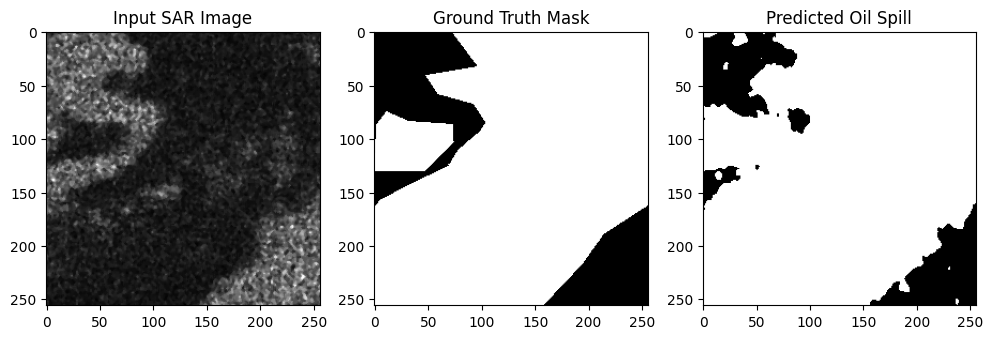

In [34]:
img, mask = test_dataset[0]

model.eval()
with torch.no_grad():
    pred = torch.sigmoid(model(img.unsqueeze(0).to(device)))[0][0].cpu().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img[0], cmap='gray')
plt.title("Input SAR Image")

plt.subplot(1,3,2)
plt.imshow(mask[0], cmap='gray')
plt.title("Ground Truth Mask")

plt.subplot(1,3,3)
plt.imshow(pred > 0.5, cmap='gray')
plt.title("Predicted Oil Spill")

plt.show()
